## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

### Step 1: Loading and Verifying the Data

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv("air_fryers_clean_brand_year.csv")

# Preview the data
print("First five rows:")
display(df.head())

print("\nData shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First five rows:


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364



Data shape:
(50, 15)

Column names:
['category', 'year', 'brand', 'purchase_count', 'product_count', 'avg_price', 'avg_rating', 'compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share', 'market_purchases', 'brand_share', 'log_brand_share']

Data types:
category              object
year                   int64
brand                 object
purchase_count         int64
product_count          int64
avg_price            float64
avg_rating           float64
compact_share        float64
dual_basket_share    float64
oven_style_share     float64
rotisserie_share     float64
window_share         float64
market_purchases       int64
brand_share          float64
log_brand_share      float64
dtype: object


In [2]:
# Check unique brands
brands = sorted(df["brand"].unique())
print("Number of brands:", df["brand"].nunique())
print("Brands:")
print(brands)

# Check years
years = sorted(df["year"].unique())
print("\nYears in data:")
print(years)

# Expected checks
expected_years = [2019, 2020, 2021, 2022, 2023]

print("\nVerification:")
print("Contains 10 brands:", df["brand"].nunique() == 10)
print("Contains years 2019–2023:", years == expected_years)
print("Expected number of rows is 50:", df.shape[0] == 10 * 5)

Number of brands: 10
Brands:
['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']

Years in data:
[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Verification:
Contains 10 brands: True
Contains years 2019–2023: True
Expected number of rows is 50: True


In [3]:
# Count rows for each brand-year pair
brand_year_counts = (
    df.groupby(["brand", "year"])
      .size()
      .reset_index(name="row_count")
)

print("Brand-year row counts:")
display(brand_year_counts)

# Check for duplicate brand-year rows
duplicates = brand_year_counts[brand_year_counts["row_count"] > 1]

print("\nDuplicate brand-year rows:")
display(duplicates)

# Check for missing brand-year combinations
all_combinations = pd.MultiIndex.from_product(
    [brands, expected_years],
    names=["brand", "year"]
)

existing_combinations = pd.MultiIndex.from_frame(df[["brand", "year"]])

missing_combinations = all_combinations.difference(existing_combinations)

print("\nMissing brand-year combinations:")
print(list(missing_combinations))

print("\nComplete brand-year panel:", len(missing_combinations) == 0 and duplicates.empty)

Brand-year row counts:


,brand,year,row_count
0,chefman,2019,1
1,chefman,2020,1
2,chefman,2021,1
3,chefman,2022,1
4,chefman,2023,1
5,cosori,2019,1
6,cosori,2020,1
7,cosori,2021,1
8,cosori,2022,1
9,cosori,2023,1



Duplicate brand-year rows:


,brand,year,row_count



Missing brand-year combinations:
[]

Complete brand-year panel: True


In [4]:
# Missing values by column
missing_values = df.isna().sum()

print("Missing values by column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found.")

Missing values by column:


,0


No missing values found.


In [5]:
numeric_columns = [
    "purchase_count",
    "product_count",
    "avg_price",
    "avg_rating",
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
    "market_purchases",
    "brand_share",
    "log_brand_share"
]

print("Numeric column type check:")
for col in numeric_columns:
    print(col, "is numeric:", pd.api.types.is_numeric_dtype(df[col]))

# Summary statistics for numeric variables
print("\nSummary statistics:")
display(df[numeric_columns].describe())

# Check whether share columns are between 0 and 1
share_columns = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
    "brand_share"
]

print("\nShare range checks:")
for col in share_columns:
    valid_range = df[col].between(0, 1).all()
    print(f"{col} between 0 and 1:", valid_range)

Numeric column type check:
purchase_count is numeric: True
product_count is numeric: True
avg_price is numeric: True
avg_rating is numeric: True
compact_share is numeric: True
dual_basket_share is numeric: True
oven_style_share is numeric: True
rotisserie_share is numeric: True
window_share is numeric: True
market_purchases is numeric: True
brand_share is numeric: True
log_brand_share is numeric: True

Summary statistics:


,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2163.860000,22.100000,122.806133,4.532899,0.980081,0.002260,0.562647,0.070762,0.036741,21638.600000,0.100000,-2.656066
std,1773.942525,14.941041,51.155468,0.129549,0.068570,0.007243,0.338648,0.122542,0.115186,8827.088216,0.072717,1.041834
min,11.000000,2.000000,55.176333,4.321901,0.542017,0.000000,0.000000,0.000000,0.000000,8400.000000,0.000730,-7.222964
25%,648.750000,10.000000,83.838999,4.415775,0.993128,0.000000,0.185735,0.000000,0.000000,15076.000000,0.050242,-2.990918
50%,1741.500000,18.500000,105.301728,4.501924,0.999191,0.000000,0.694366,0.000000,0.000000,23576.000000,0.078620,-2.543178
75%,3058.250000,31.750000,155.059630,4.652666,1.000000,0.000000,0.846168,0.124260,0.000000,30291.000000,0.142418,-1.949027
max,6756.000000,61.000000,229.465274,4.778650,1.000000,0.034520,0.973431,0.511073,0.485465,30850.000000,0.292186,-1.230364



Share range checks:
compact_share between 0 and 1: True
dual_basket_share between 0 and 1: True
oven_style_share between 0 and 1: True
rotisserie_share between 0 and 1: True
window_share between 0 and 1: True
brand_share between 0 and 1: True


In [7]:
# Check whether brand shares sum to 1 by year
share_sums = (
    df.groupby("year")["brand_share"]
      .sum()
      .reset_index(name="total_brand_share")
)

print("Brand share totals by year:")
display(share_sums)

# Allow a tiny rounding tolerance
share_sums["approximately_1"] = share_sums["total_brand_share"].round(6) == 1.0

print("\nDo brand shares sum to 1 each year?")
display(share_sums)

Brand share totals by year:


,year,total_brand_share
0,2019,1.0
1,2020,1.0
2,2021,1.0
3,2022,1.0
4,2023,1.0



Do brand shares sum to 1 each year?


,year,total_brand_share,approximately_1
0,2019,1.0,True
1,2020,1.0,True
2,2021,1.0,True
3,2022,1.0,True
4,2023,1.0,True


In [6]:
print(
    f"The dataset contains {df['brand'].nunique()} brands and years "
    f"{min(df['year'])}–{max(df['year'])}. "
    f"There are {df.shape[0]} rows, representing brand-year observations."
)

The dataset contains 10 brands and years 2019–2023. There are 50 rows, representing brand-year observations.


#### Data Verification Summary

The dataset loaded successfully and contains 50 brand-year observations, representing 10 air fryer brands across the years 2019–2023. Each brand appears exactly once in each year, so the dataset forms a complete brand-year panel with no missing brand-year combinations and no duplicate rows.

The data contain no missing values, and all key numeric columns are stored in the correct numeric format. All share variables fall within the expected 0 to 1 range. Overall, the dataset appears clean, complete, and ready for exploratory analysis and visualization.

### Step 2: Plotting

In [8]:
# Import necessary packages
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [13]:
# Create cleaner brand labels for plots
brand_name_map = {
    "chefman": "Chefman",
    "cosori": "Cosori",
    "cuisinart": "Cuisinart",
    "dash": "Dash",
    "gowise usa": "GoWISE USA",
    "instant_pot": "Instant Pot",
    "ninja": "Ninja",
    "nuwave": "NuWave",
    "oster": "Oster",
    "ultrean": "Ultrean"
}

df_plot = df.copy()
df_plot["brand_label"] = df_plot["brand"].map(brand_name_map)

# Sort for cleaner line plots
df_plot = df_plot.sort_values(["brand_label", "year"])

In [15]:
# Define a reusable plotting function to create clean brand-level line charts.
# This keeps the formatting consistent across the price, rating, and market
# share plots.

def plot_brand_lines(data, y_col, title, y_label, percent_axis=False):
    """
    Plot a line chart over time for each brand.
    """
    fig, ax = plt.subplots(figsize=(11, 6))

    for brand in sorted(data["brand_label"].unique()):
        brand_data = data[data["brand_label"] == brand]
        ax.plot(
            brand_data["year"],
            brand_data[y_col],
            marker="o",
            linewidth=2,
            markersize=5,
            label=brand
        )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)

    ax.set_xticks(sorted(data["year"].unique()))

    if percent_axis:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Brand",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()

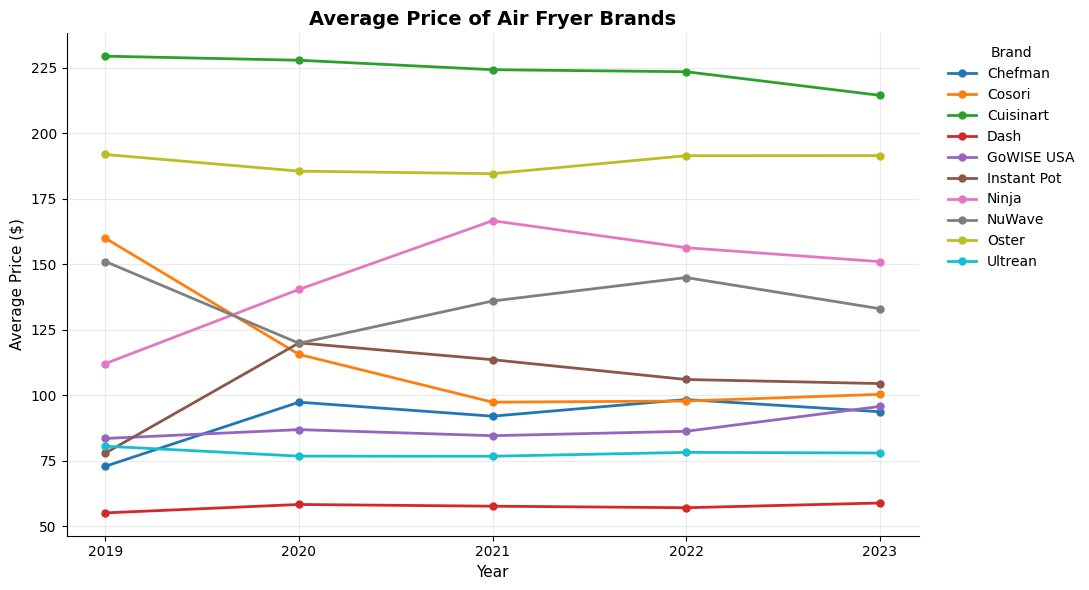

In [27]:
# Creating a plot to show average price over time
plot_brand_lines(
    data=df_plot,
    y_col="avg_price",
    title="Average Price of Air Fryer Brands",
    y_label="Average Price ($)"
)

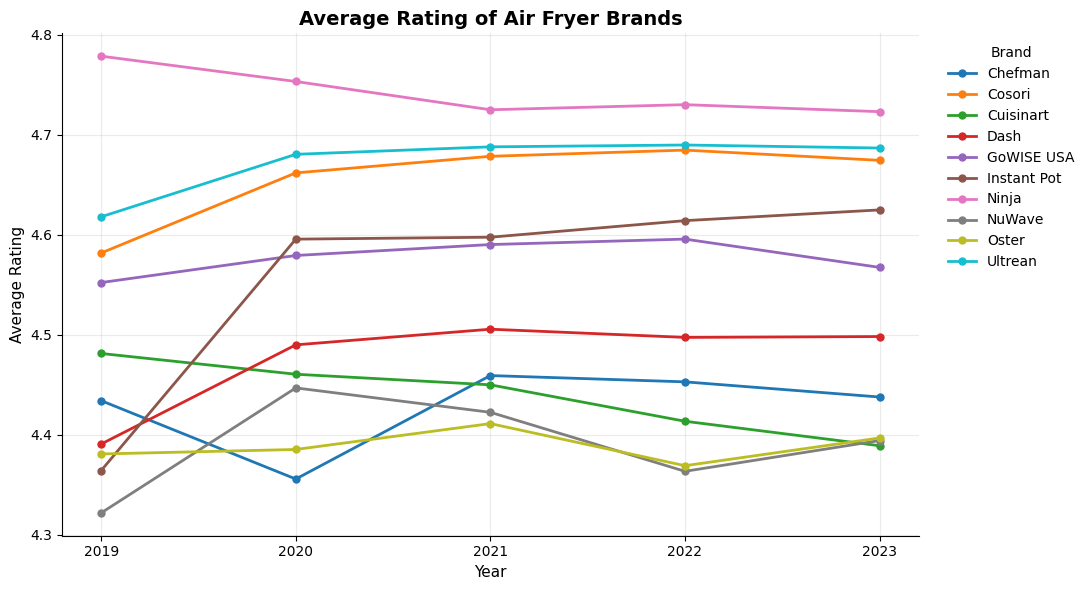

In [28]:
# Creating a plot to show average rating over time
plot_brand_lines(
    data=df_plot,
    y_col="avg_rating",
    title="Average Rating of Air Fryer Brands",
    y_label="Average Rating"
)

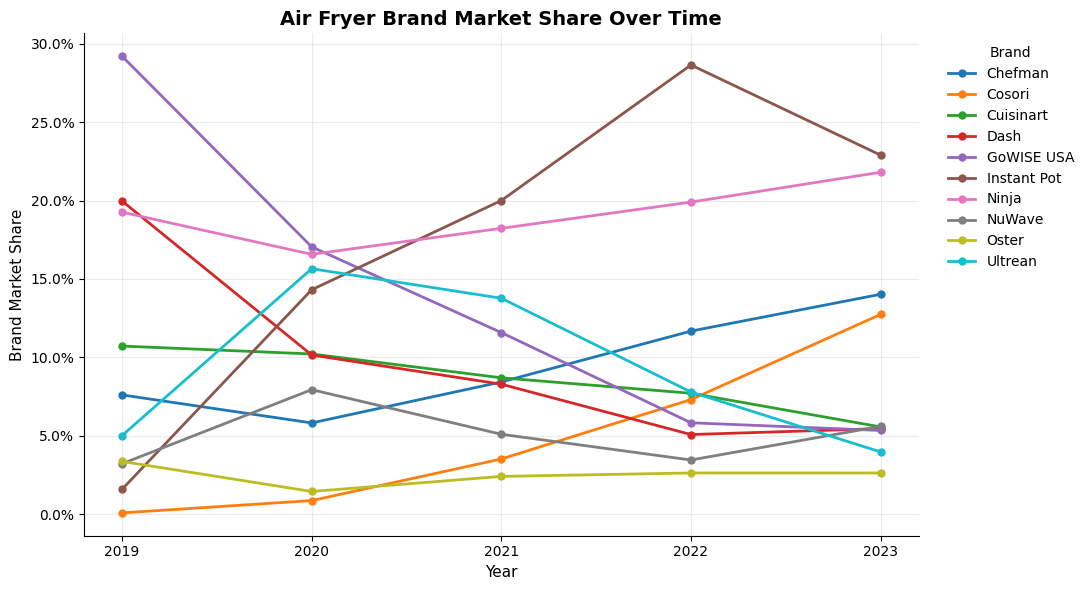

In [21]:
# Creating a plot to show market share over time
plot_brand_lines(
    data=df_plot,
    y_col="brand_share",
    title="Air Fryer Brand Market Share Over Time",
    y_label="Brand Market Share",
    percent_axis=True
)

In [29]:
# Creating a summary table to display overall results
brand_summary = (
    df_plot.groupby("brand_label")
      .agg(
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean"),
          avg_brand_share=("brand_share", "mean")
      )
      .sort_values("avg_brand_share", ascending=False)
)

display(brand_summary)

,avg_price,avg_rating,avg_brand_share
brand_label,,,
Ninja,145.342541,4.742064,0.191567
Instant Pot,104.461353,4.559323,0.174921
GoWISE USA,87.454781,4.576990,0.138005
Dash,57.478927,4.476394,0.097862
Chefman,90.938411,4.427966,0.095079
Ultrean,78.114606,4.672616,0.092369
Cuisinart,223.947093,4.438892,0.085787
NuWave,137.024384,4.389798,0.050559
Cosori,114.267950,4.656292,0.048974


#### Data Plotting Summary

The plots show how average price, average rating, and  market share change by brand from 2019 to 2023. These visuals provide an initial comparison of brand trends over time and will be used to support the broader market interpretation.

### Step 3: Product Characteristics

In [31]:
# Defining product feature columns
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

# Cleaner feature labels for tables and plots
feature_name_map = {
    "compact_share": "Compact",
    "dual_basket_share": "Dual Basket",
    "oven_style_share": "Oven Style",
    "rotisserie_share": "Rotisserie",
    "window_share": "Window"
}

In [32]:
# Summarize each product feature across all brand-year observations
feature_summary = (
    df[feature_cols]
    .agg(["mean", "min", "max"])
    .T
    .reset_index()
    .rename(columns={
        "index": "feature",
        "mean": "average_share",
        "min": "minimum_share",
        "max": "maximum_share"
    })
)

# Count how often each feature appears at all
feature_summary["brand_years_present"] = [
    (df[col] > 0).sum() for col in feature_cols
]

# Add cleaner feature names
feature_summary["feature"] = feature_summary["feature"].map(feature_name_map)

# Sort from most common to least common
feature_summary = feature_summary.sort_values("average_share", ascending=False)

display(feature_summary)

,feature,average_share,minimum_share,maximum_share,brand_years_present
0,Compact,0.980081,0.542017,1.000000,50
2,Oven Style,0.562647,0.000000,0.973431,49
3,Rotisserie,0.070762,0.000000,0.511073,23
4,Window,0.036741,0.000000,0.485465,9
1,Dual Basket,0.002260,0.000000,0.034520,9


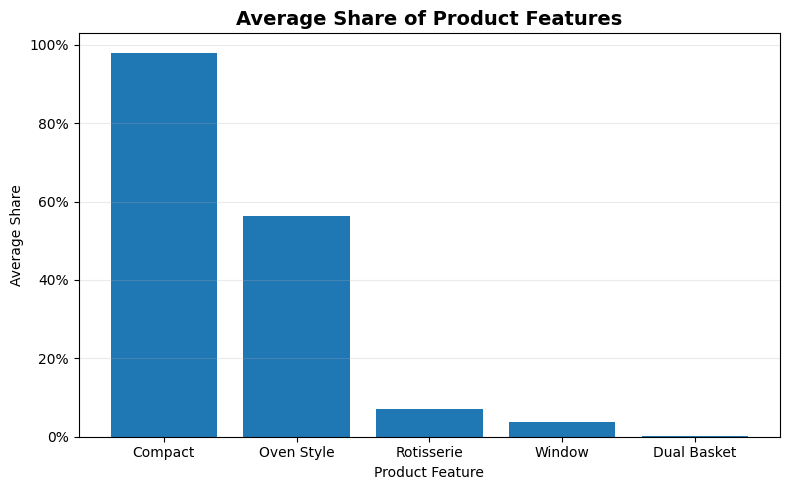

In [35]:
# Creating a bar chart for feature commonality
plt.figure(figsize=(8, 5))

plt.bar(
    feature_summary["feature"],
    feature_summary["average_share"]
)

plt.title("Average Share of Product Features", fontsize=14, fontweight="bold")
plt.xlabel("Product Feature")
plt.ylabel("Average Share")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Compact products are the dominant product type across all brands, and oven-style products are the most common secondary feature. Because these two features are common for most brands, brand specialization is better evaluated by comparing which brands have the highest average share for each individual feature rather than by selecting only the highest feature within each brand.

In [42]:
# Calculate average feature shares by brand
brand_feature_summary = (
    df_plot.groupby("brand_label")[feature_cols]
    .mean()
    .rename(columns=feature_name_map)
)

display(
    brand_feature_summary
    .sort_values("Oven Style", ascending=False)
    .style.format("{:.1%}")
)

,Compact,Dual Basket,Oven Style,Rotisserie,Window
brand_label,,,,,
Cuisinart,99.6%,0.0%,91.3%,0.0%,0.0%
Dash,99.9%,0.0%,89.0%,0.0%,0.0%
Oster,100.0%,0.0%,86.5%,0.0%,0.0%
Ultrean,100.0%,0.0%,83.0%,0.0%,0.0%
Instant Pot,86.0%,0.0%,67.5%,10.2%,0.3%
Chefman,96.2%,1.3%,59.7%,37.0%,36.3%
NuWave,99.5%,0.7%,54.3%,2.7%,0.0%
GoWISE USA,100.0%,0.0%,18.4%,18.4%,0.1%
Ninja,99.2%,0.2%,10.0%,0.0%,0.0%


In [46]:
# Identify brands within 1 percentage point of the highest average share for each feature
top_brands_by_feature = []

for feature in brand_feature_summary.columns:
    top_share = brand_feature_summary[feature].max()
    threshold = top_share - 0.01

    top_brands = (
        brand_feature_summary[brand_feature_summary[feature] >= threshold]
        .index
        .tolist()
    )

    top_brands_by_feature.append({
        "feature": feature,
        "top_or_near_top_brands": ", ".join(top_brands),
        "top_average_share": top_share
    })

top_brands_by_feature = pd.DataFrame(top_brands_by_feature)

top_brands_by_feature = top_brands_by_feature.sort_values(
    "top_average_share",
    ascending=False
)

display(
    top_brands_by_feature.style.format({
        "top_average_share": "{:.1%}"
    })
)

,feature,top_or_near_top_brands,top_average_share
0,Compact,"Cosori, Cuisinart, Dash, GoWISE USA, Ninja, NuWave, Oster, Ultrean",100.0%
2,Oven Style,Cuisinart,91.3%
3,Rotisserie,Chefman,37.0%
4,Window,Chefman,36.3%
1,Dual Basket,"Chefman, NuWave",1.3%


#### Product Characteristics Summary

The analysis shows that compact products are the most common product type in the dataset. The average compact share is very high, and compact products appear across all brand-year observations. Oven-style products are also common, appearing in nearly every brand-year observation, but with more variation across brands.

The rarer features are dual basket, window, and rotisserie designs. Dual basket products are especially rare, with a very low average share overall. Window and rotisserie features appear more often than dual basket, but they are still much less common than compact or oven-style products.

There is some evidence that brands specialize in different product types. Cuisinart has the highest average oven-style share, while Chefman stands out for rotisserie and window features. Chefman and NuWave are also the top or near-top brands for dual basket products, although dual basket products are rare overall. Compact products are not a useful specialization signal because they are common across nearly all brands.

### Step 4: Market Summary

In [47]:
# Summary table to support the market description
market_summary = (
    df_plot.groupby("brand_label")
    .agg(
        avg_price=("avg_price", "mean"),
        avg_rating=("avg_rating", "mean"),
        avg_brand_share=("brand_share", "mean")
    )
    .sort_values("avg_brand_share", ascending=False)
)

display(
    market_summary.style.format({
        "avg_price": "${:.2f}",
        "avg_rating": "{:.2f}",
        "avg_brand_share": "{:.1%}"
    })
)

,avg_price,avg_rating,avg_brand_share
brand_label,,,
Ninja,$145.34,4.74,19.2%
Instant Pot,$104.46,4.56,17.5%
GoWISE USA,$87.45,4.58,13.8%
Dash,$57.48,4.48,9.8%
Chefman,$90.94,4.43,9.5%
Ultrean,$78.11,4.67,9.2%
Cuisinart,$223.95,4.44,8.6%
NuWave,$137.02,4.39,5.1%
Cosori,$114.27,4.66,4.9%


The air fryer market appears to have a few larger brands and several smaller brands. Ninja, Instant Pot, and GoWISE USA have the largest average market shares over the 2019–2023 period, with Ninja showing the strongest overall position. The most expensive brands are Cuisinart and Oster, while Ninja and NuWave are also relatively higher-priced compared with several lower-priced brands such as Dash and Ultrean. As for market stability, there are some noteworthy changes over time. Ninja remains consistently large, but other brands shift more noticeably: Instant Pot gains substantial share after 2019, GoWISE USA declines over time, and Cosori grows from a very small share to a more meaningful presence by 2023. Overall, the market shows some stable leaders but also meaningful movement in brand shares across the five-year period.